Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install opencv-python scikit-image pywavelets imbalanced-learn

Imports & Installs

In [ ]:
!pip install opencv-python scikit-image pywavelets imbalanced-learn

import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

import pywt

Dataset Paths

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/dataset_split"

TRAIN_PATH = DATASET_ROOT + "/train"
VAL_PATH   = DATASET_ROOT + "/valid"
TEST_PATH  = DATASET_ROOT + "/test"

Raw image check

In [ ]:
def load_image(path, size=(200, 200)):
    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    return img

Image Resize (200×200)

Image path: /content/drive/MyDrive/dataset_split/train/First Degree Burn Superficial Thickness/img1368_jpg.rf.1026415bb1140a2d5a55bc3f9585d40b.jpg


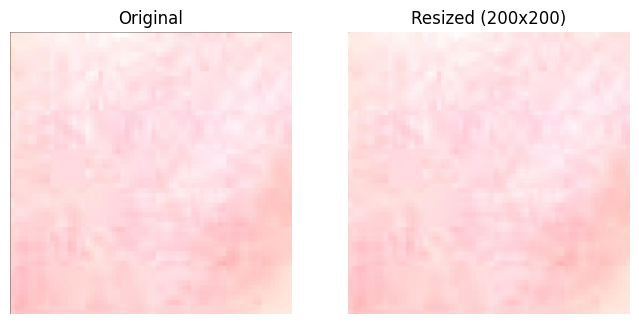

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# Path
dataset = "/content/drive/MyDrive/dataset_split/train"

# Pick first class
cls = os.listdir(dataset)[0]

# Pick one image (you already showed names)
img_name = os.listdir(os.path.join(dataset, cls))[0]

img_path = os.path.join(dataset, cls, img_name)

print("Image path:", img_path)

# Load image
img = cv2.imread(img_path)

if img is None:
    print("❌ Image not loaded")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(img, (200, 200))

    # Show
    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(resized)
    plt.title("Resized (200x200)")
    plt.axis("off")

    plt.show()

Hybrid Segmentation (Skin detection (RGB rule))



In [ ]:
def skin_mask_rgb(image):

    R, G, B = image[:,:,0], image[:,:,1], image[:,:,2]

    mask = (
        (R > 95) &
        (G > 40) &
        (B > 20) &
        ((np.max(image, axis=2) - np.min(image, axis=2)) > 15) &
        (R > G) &
        (R > B)
    )

    return mask.astype(np.uint8)

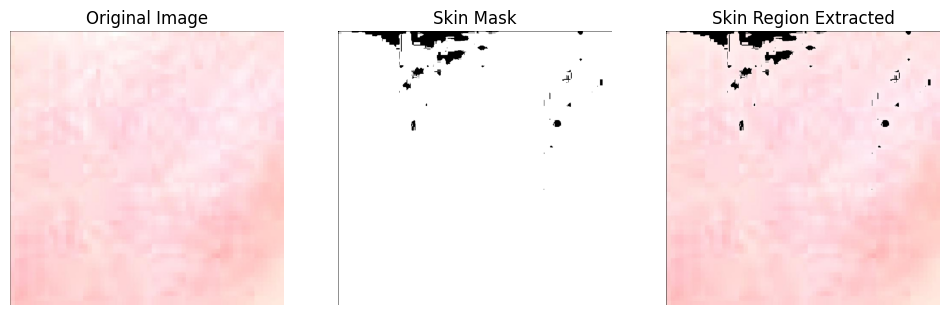

In [ ]:
dataset = "/content/drive/MyDrive/dataset_split/train"

cls = os.listdir(dataset)[0]
img_name = os.listdir(os.path.join(dataset, cls))[0]

img_path = os.path.join(dataset, cls, img_name)

def show_skin_mask(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found!")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = skin_mask_rgb(img)

    # Convert mask for visualization
    mask_vis = mask * 255

    # Apply mask
    segmented = cv2.bitwise_and(img, img, mask=mask_vis.astype(np.uint8))

    plt.figure(figsize=(12,4))

    # Original
    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    # Mask
    plt.subplot(1,3,2)
    plt.imshow(mask_vis, cmap='gray')
    plt.title("Skin Mask")
    plt.axis("off")

    # Segmented
    plt.subplot(1,3,3)
    plt.imshow(segmented)
    plt.title("Skin Region Extracted")
    plt.axis("off")

    plt.show()

show_skin_mask(img_path)

In [ ]:
def burn_segmentation_lab(image):

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    a = lab[:,:,1]

    a_blur = cv2.GaussianBlur(a, (5,5), 0)

    _, mask = cv2.threshold(
        a_blur,
        0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return mask // 255

Hybrid Segmentation(Burn segmentation(LAB* rule))



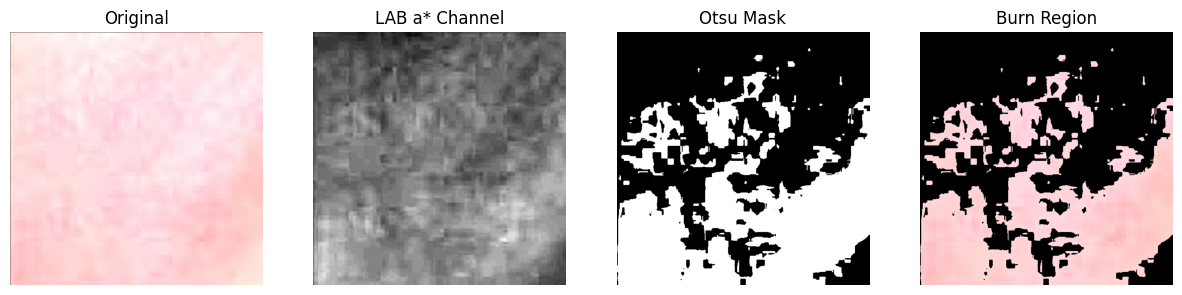

In [ ]:
def burn_segmentation_lab(image):

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    a = lab[:,:,1]  # a* channel

    a_blur = cv2.GaussianBlur(a, (5,5), 0)

    _, mask = cv2.threshold(
        a_blur,
        0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return a, a_blur, mask
    import matplotlib.pyplot as plt
import cv2

def show_burn_segmentation(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found!")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get steps
    a, a_blur, mask = burn_segmentation_lab(img)

    segmented = cv2.bitwise_and(img, img, mask=mask)

    plt.figure(figsize=(15,4))

    # Original
    plt.subplot(1,4,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    # a* channel
    plt.subplot(1,4,2)
    plt.imshow(a, cmap='gray')
    plt.title("LAB a* Channel")
    plt.axis("off")

    # Otsu mask
    plt.subplot(1,4,3)
    plt.imshow(mask, cmap='gray')
    plt.title("Otsu Mask")
    plt.axis("off")

    # Final segmented burn
    plt.subplot(1,4,4)
    plt.imshow(segmented)
    plt.title("Burn Region")
    plt.axis("off")

    plt.show()
    dataset = "/content/drive/MyDrive/dataset/dataset_split/train"

cls = os.listdir(dataset)[0]
img_name = os.listdir(os.path.join(dataset, cls))[0]

img_path = os.path.join(dataset, cls, img_name)

show_burn_segmentation(img_path)

Post Processing (Morphology)

In [ ]:
def post_process(mask):

    kernel = np.ones((5,5), np.uint8)

    mask = cv2.dilate(mask, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.erode(mask, kernel, iterations=1)

    return mask

GLCM Features (Texture)

In [ ]:
def glcm_features(gray):

    gray = (gray * 255).astype(np.uint8)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return [
        graycoprops(glcm, 'contrast')[0,0],
        graycoprops(glcm, 'correlation')[0,0],
        graycoprops(glcm, 'energy')[0,0],
        graycoprops(glcm, 'homogeneity')[0,0]
    ]

DWT Features

In [ ]:
def dwt_features(gray):

    coeffs = pywt.dwt2(gray, 'haar')
    cA, (cH, cV, cD) = coeffs

    return [
        np.mean(cA), np.std(cA),
        np.mean(cH), np.std(cH),
        np.mean(cV), np.std(cV),
        np.mean(cD), np.std(cD)
    ]

FULL Feature Extraction Pipeline

In [ ]:
def extract_features(image):

    # ---------------------------
    # Segmentation
    # ---------------------------
    skin = skin_mask_rgb(image)
    # Unpack the tuple from burn_segmentation_lab to get only the mask
    _, burn = burn_segmentation_lab(image)
    burn = post_process(burn)

    mask = burn

    segmented = cv2.bitwise_and(image, image, mask=mask.astype(np.uint8))

    # ---------------------------
    # Color Features (Lab)
    # ---------------------------
    lab = cv2.cvtColor(segmented, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    color_features = [
        np.mean(l), np.mean(a), np.mean(b),
        np.std(l), np.std(a), np.std(b)
    ]

    # ---------------------------
    # Gray Image
    # ---------------------------
    gray = cv2.cvtColor(segmented, cv2.COLOR_RGB2GRAY) / 255.0

    # ---------------------------
    # Basic Texture
    # ---------------------------
    basic_texture = [
        np.mean(gray),
        np.std(gray),
        np.var(gray)
    ]

    # ---------------------------
    # GLCM
    # ---------------------------
    glcm_feat = glcm_features(gray)

    # ---------------------------
    # DWT
    # ---------------------------
    dwt_feat = dwt_features(gray)

    return color_features + basic_texture + glcm_feat + dwt_feat

Full pipeline comparison

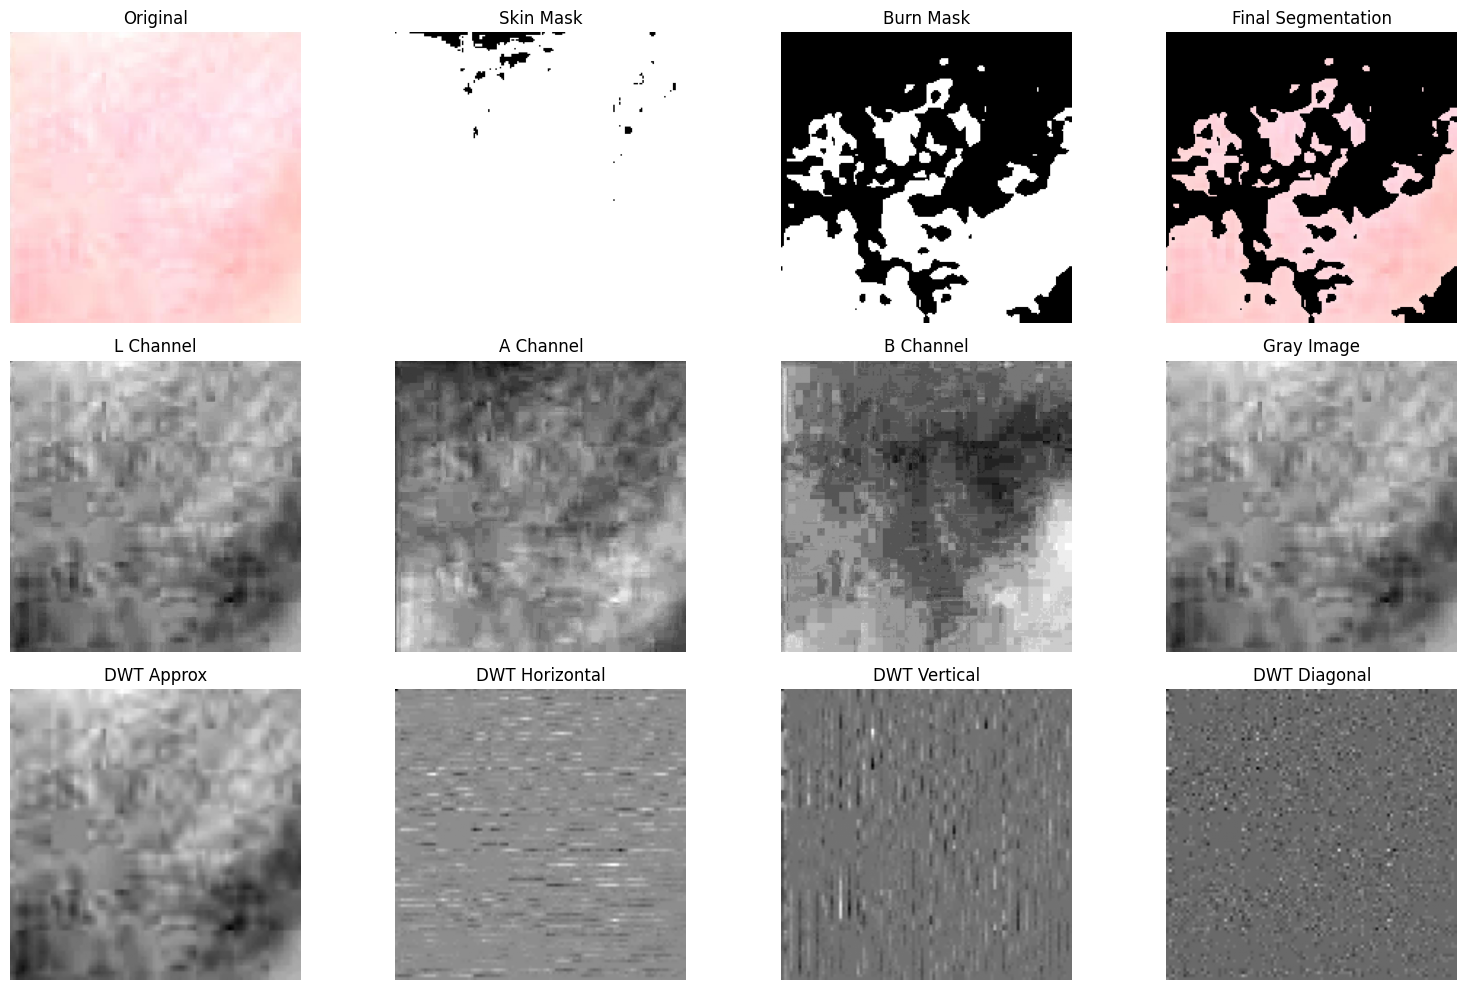

In [ ]:
%matplotlib inline
def burn_segmentation_lab(image):
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    a = lab[:,:,1]

    a_blur = cv2.GaussianBlur(a, (5,5), 0)

    _, mask = cv2.threshold(
        a_blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return a, mask

# -----------------------------
# FULL VISUALIZATION
# -----------------------------
def show_all_features(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200,200))

    # --- Skin mask ---
    skin = skin_mask_rgb(img) * 255

    # --- Burn mask ---
    a, burn = burn_segmentation_lab(img)

    # --- Combine ---
    final_mask = cv2.bitwise_and(skin, burn)
    segmented = cv2.bitwise_and(img, img, mask=final_mask)

    # --- LAB ---
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a_ch, b = cv2.split(lab)

    # --- Gray ---
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # --- DWT ---
    coeffs = pywt.dwt2(gray, 'haar')
    cA, (cH, cV, cD) = coeffs

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=(16,10))

    titles = [
        "Original", "Skin Mask", "Burn Mask", "Final Segmentation",
        "L Channel", "A Channel", "B Channel", "Gray Image",
        "DWT Approx", "DWT Horizontal", "DWT Vertical", "DWT Diagonal"
    ]

    images = [
        img, skin, burn, segmented,
        l, a_ch, b, gray,
        cA, cH, cV, cD
    ]

    for i in range(len(images)):
        plt.subplot(3,4,i+1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
def show_image(img, title="image"):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=None)
    plt.title(title)
    plt.axis("off")
    plt.show()
dataset = "/content/drive/MyDrive/dataset_split/train"

cls = os.listdir(dataset)[0]
img_name = os.listdir(os.path.join(dataset, cls))[0]

img_path = os.path.join(dataset, cls, img_name)

show_all_features(img_path)

Dataset Builder

In [ ]:
def build_dataset(path):

    X, y = [], []

    class_names = sorted(os.listdir(path))

    for label in class_names:
        class_path = os.path.join(path, label)

        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = load_image(img_path)
            if img is None:
                continue

            features = extract_features(img)

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)

Encode Labels

In [ ]:
X_train, y_train = build_dataset(TRAIN_PATH)
X_val, y_val     = build_dataset(VAL_PATH)
X_test, y_test   = build_dataset(TEST_PATH)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (10817, 21)
Val: (2316, 21)
Test: (2323, 21)


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {gpus[0].name}")
else:
    print("No GPU available.")
    print("To enable a GPU runtime, go to the menu: 'Runtime' > 'Change runtime type' > 'Hardware accelerator' and select 'GPU'.")

GPU available: /physical_device:GPU:0


Encode Labels

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

PCA (Feature Reduction)

In [ ]:
pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_val   = pca.transform(X_val)
X_test  = pca.transform(X_test)

print("After PCA:", X_train.shape)

After PCA: (10817, 10)


Model Training

In [ ]:
# Re-initialize and re-train the model on PCA-transformed data
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=1000,
    max_features=0.5,
    bootstrap=False,
    random_state=42
)

# Train model on the PCA-transformed X_train
model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Validation Accuracy:", model.score(X_val, y_val))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9924193399278913
Validation Accuracy: 0.6450777202072538
Test Accuracy: 0.6448557899268188


In [ ]:
# ✅ Random Subspace Model
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=1000,
    max_features=0.5,   # uses 50% of features randomly
    bootstrap=False,    # disables row sampling (pure subspace method)
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6448557899268188
              precision    recall  f1-score   support

           0       0.68      0.33      0.45       496
           1       0.85      0.28      0.42       148
           2       0.61      0.82      0.70       959
           3       0.67      0.70      0.69       720

    accuracy                           0.64      2323
   macro avg       0.70      0.53      0.56      2323
weighted avg       0.66      0.64      0.62      2323



Per class accuracy plot

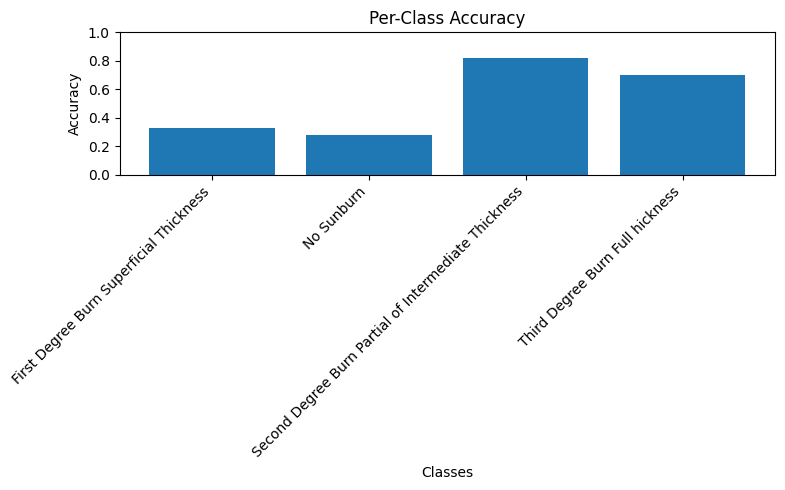

In [ ]:
import matplotlib.pyplot as plt

# Get class names from the LabelEncoder
class_names = le.inverse_transform(np.arange(len(le.classes_)))

# Calculate per-class accuracy
per_class_acc = []
for i in np.arange(len(le.classes_)):
    class_indices = np.where(y_test == i)
    correct_predictions = (y_pred[class_indices] == y_test[class_indices]).sum()
    total_predictions = len(class_indices[0])
    if total_predictions > 0:
        per_class_acc.append(correct_predictions / total_predictions)
    else:
        per_class_acc.append(0.0)

plt.figure(figsize=(8,5))
plt.bar(class_names, per_class_acc)
plt.ylim(0,1)
plt.title("Per-Class Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Classes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Confusion Metrics plot

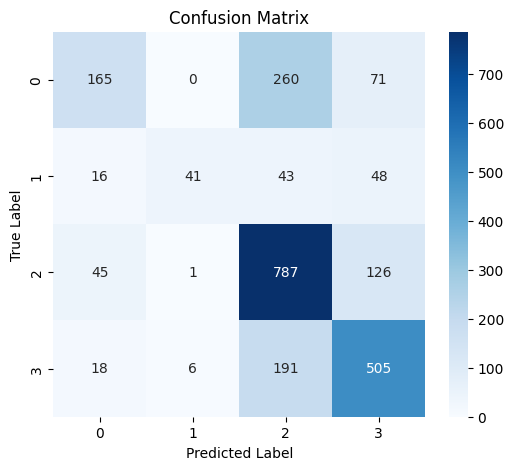

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Normalised confusion matrix



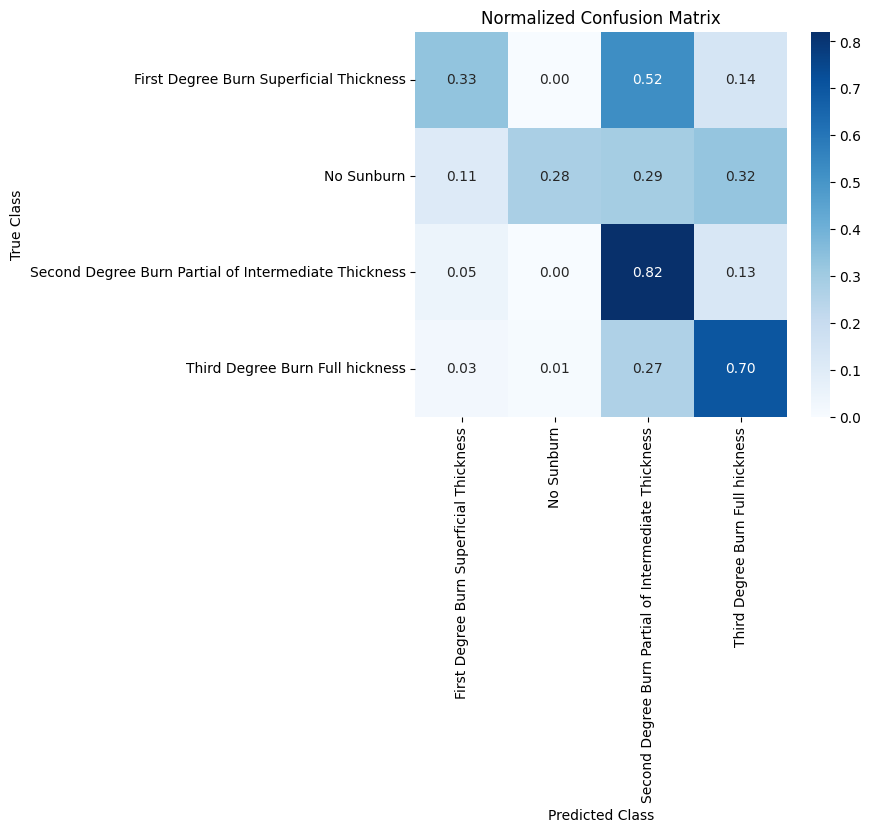

In [ ]:
import numpy as np

cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

Train, Test, Validation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
y_train_pred = model.predict(X_train)
y_val_pred   = model.predict(X_val)
y_test_pred  = model.predict(X_test)
def print_metrics(y_true, y_pred, name="Dataset"):

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')

    print(f"\n{name} Metrics")
    print("-"*30)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_val, y_val_pred, "Validation")
print_metrics(y_test, y_test_pred, "Test")




Train Metrics
------------------------------
Accuracy : 0.9924
Precision: 0.9925
Recall   : 0.9924
F1-score : 0.9924

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2307
           1       1.00      1.00      1.00       685
           2       0.99      0.99      0.99      4471
           3       1.00      0.99      0.99      3354

    accuracy                           0.99     10817
   macro avg       0.99      0.99      0.99     10817
weighted avg       0.99      0.99      0.99     10817


Validation Metrics
------------------------------
Accuracy : 0.6451
Precision: 0.6630
Recall   : 0.6451
F1-score : 0.6239

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.32      0.43       494
           1       0.84      0.26      0.40       146
           2       0.60      0.84      0.70       958
           3       0.71      0.69      0.70       718

    

TABLE FORMAT of Accuracy,Precision, Recall, F1-score



In [ ]:
import pandas as pd

def get_metrics(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ]

data = [
    get_metrics(y_train, y_train_pred),
    get_metrics(y_val, y_val_pred),
    get_metrics(y_test, y_test_pred)
]

df = pd.DataFrame(
    data,
    columns=["Accuracy", "Precision", "Recall", "F1-score"],
    index=["Train", "Validation", "Test"]
)

print(df)

            Accuracy  Precision    Recall  F1-score
Train       0.992419   0.992489  0.992419  0.992427
Validation  0.645078   0.663026  0.645078  0.623916
Test        0.644856   0.661128  0.644856  0.624912


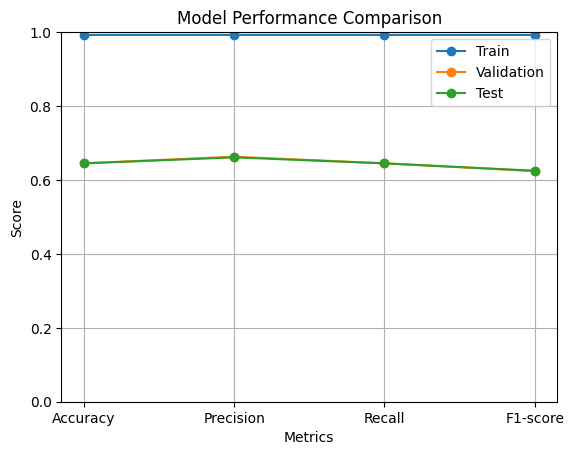

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Calculate metrics
# -----------------------------
train_metrics = [
    accuracy_score(y_train, y_train_pred),
    precision_score(y_train, y_train_pred, average='weighted'),
    recall_score(y_train, y_train_pred, average='weighted'),
    f1_score(y_train, y_train_pred, average='weighted')
]

val_metrics = [
    accuracy_score(y_val, y_val_pred),
    precision_score(y_val, y_val_pred, average='weighted'),
    recall_score(y_val, y_val_pred, average='weighted'),
    f1_score(y_val, y_val_pred, average='weighted')
]

test_metrics = [
    accuracy_score(y_test, y_test_pred),
    precision_score(y_test, y_test_pred, average='weighted'),
    recall_score(y_test, y_test_pred, average='weighted'),
    f1_score(y_test, y_test_pred, average='weighted')
]

labels = ["Accuracy", "Precision", "Recall", "F1-score"]

# -----------------------------
# Plot
# -----------------------------
x = range(len(labels))

plt.figure()

plt.plot(x, train_metrics, marker='o', label="Train")
plt.plot(x, val_metrics, marker='o', label="Validation")
plt.plot(x, test_metrics, marker='o', label="Test")

plt.xticks(x, labels)
plt.ylim(0, 1)

plt.title("Model Performance Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")

plt.legend()
plt.grid(True)

plt.show()

Per class Accuracy,Precision, Recall, F1-score

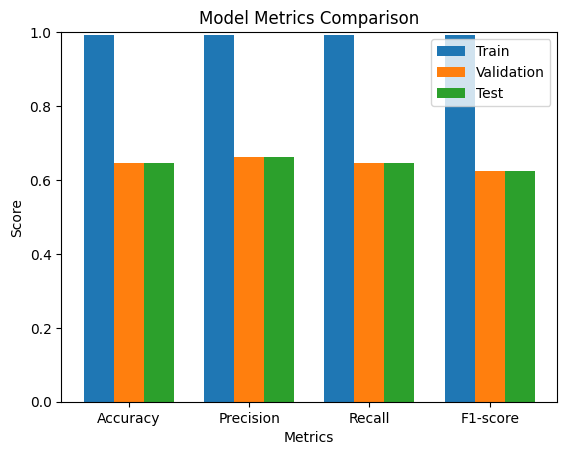

In [ ]:
plt.figure()

width = 0.25
x = range(len(labels))

plt.bar([i - width for i in x], train_metrics, width=width, label="Train")
plt.bar(x, val_metrics, width=width, label="Validation")
plt.bar([i + width for i in x], test_metrics, width=width, label="Test")

plt.xticks(x, labels)
plt.ylim(0,1)

plt.title("Model Metrics Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")

plt.legend()
plt.show()

Per-Class Accuracy Graph

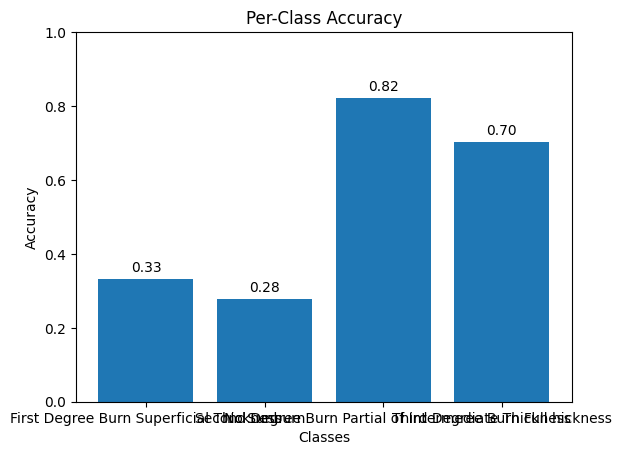

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

# -----------------------------
# Per-class accuracy (recall)
# -----------------------------
per_class_acc = cm.diagonal() / cm.sum(axis=1)

# Class names
class_names = le.classes_

# -----------------------------
# Plot
# -----------------------------
plt.figure()

plt.bar(class_names, per_class_acc)

plt.ylim(0, 1)
plt.title("Per-Class Accuracy")
plt.xlabel("Classes")
plt.ylabel("Accuracy")

# Show values on top
for i, v in enumerate(per_class_acc):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

Per-Class Precision / Recall / F1 Graph


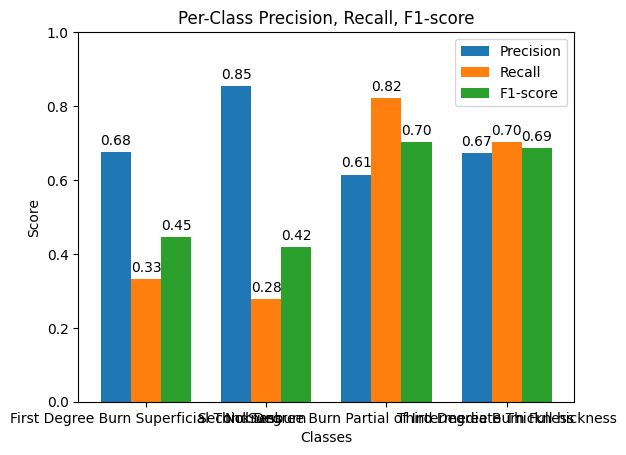

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support

# -----------------------------
# Get per-class metrics
# -----------------------------
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred)

# Class names
class_names = le.classes_

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(class_names))
width = 0.25

plt.figure()

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, class_names)
plt.ylim(0, 1)

plt.title("Per-Class Precision, Recall, F1-score")
plt.xlabel("Classes")
plt.ylabel("Score")

plt.legend()

# Show values
for i in range(len(class_names)):
    plt.text(i - width, precision[i] + 0.02, f"{precision[i]:.2f}", ha='center')
    plt.text(i, recall[i] + 0.02, f"{recall[i]:.2f}", ha='center')
    plt.text(i + width, f1[i] + 0.02, f"{f1[i]:.2f}", ha='center')

plt.show()

Multi-Class ROC Curve

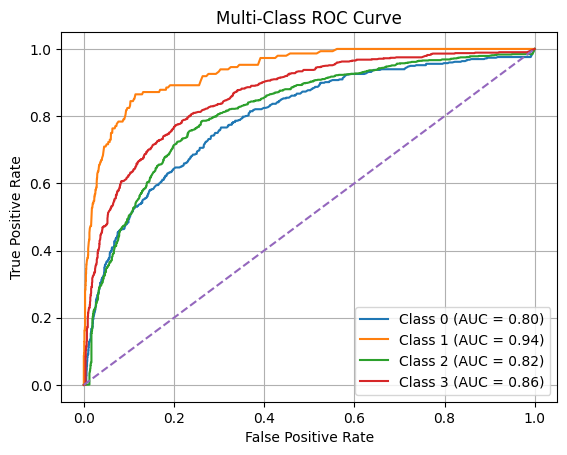

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# -----------------------------
# Binarize labels (One-vs-Rest)
# -----------------------------
n_classes = len(np.unique(y_test))

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# -----------------------------
# Get prediction probabilities
# -----------------------------
y_score = model.predict_proba(X_test)

# -----------------------------
# Compute ROC for each class
# -----------------------------
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# -----------------------------
# Plot ROC curves
# -----------------------------
plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("Multi-Class ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

Micro-Average ROC

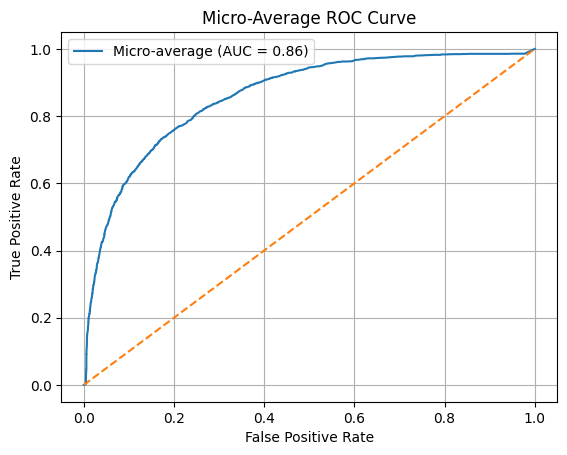

In [ ]:
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average (AUC = {roc_auc['micro']:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-Average ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import time

# Re-initialize the model to measure training time accurately
model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_features=0.5,
    bootstrap=False,
    random_state=42
)

start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()
train_time = end_time - start_time
print(f"Training Time: {train_time:.4f} seconds")

Training Time: 18.3429 seconds


In [ ]:
start_time = time.time()
y_train_pred = model.predict(X_train)
end_time = time.time()
train_predict_time = end_time - start_time
print(f"Training Prediction Time: {train_predict_time:.4f} seconds")

Training Prediction Time: 0.3926 seconds


In [ ]:
start_time = time.time()
y_val_pred = model.predict(X_val)
end_time = time.time()
val_predict_time = end_time - start_time
print(f"Validation Prediction Time: {val_predict_time:.4f} seconds")

Validation Prediction Time: 0.0872 seconds


In [ ]:
start_time = time.time()
y_test_pred = model.predict(X_test)
end_time = time.time()
test_predict_time = end_time - start_time
print(f"Test Prediction Time: {test_predict_time:.4f} seconds")

Test Prediction Time: 0.1230 seconds


Save model

In [ ]:
import joblib

# Save everything together
joblib.dump({
    "model": model,
    "scaler": scaler,
    "pca": pca,
    "label_encoder": le
}, "/content/drive/MyDrive/burn_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


Load model

In [ ]:
import joblib

data = joblib.load("/content/drive/MyDrive/burn_model.pkl")

model = data["model"]
scaler = data["scaler"]
pca = data["pca"]
le = data["label_encoder"]

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


The phrase `Simple Logistic model` was removed from the `import pywt` line as it is not a valid component to import from the `pywavelets` library. If you intended to use a Logistic Regression model, it is usually found in `sklearn.linear_model`.

Hardware & resources

In [ ]:
!pip install psutil

In [ ]:
import platform
import psutil
import torch

print("===== SYSTEM INFO =====")

# OS + Python
print("OS:", platform.system(), platform.release())
print("Python Version:", platform.python_version())

# CPU
print("\nCPU:", platform.machine())
print("CPU Cores:", psutil.cpu_count(logical=True))

# RAM
ram = psutil.virtual_memory()
print("\nTotal RAM:", round(ram.total / (1024**3), 2), "GB")
print("Available RAM:", round(ram.available / (1024**3), 2), "GB")
print("Used RAM:", round(ram.used / (1024**3), 2), "GB")

# Disk
disk = psutil.disk_usage('/')
print("\nTotal Disk:", round(disk.total / (1024**3), 2), "GB")
print("Used Disk:", round(disk.used / (1024**3), 2), "GB")
print("Free Disk:", round(disk.free / (1024**3), 2), "GB")

# GPU
print("\n===== GPU INFO =====")

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())

    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    reserved = torch.cuda.memory_reserved(0) / (1024**3)

    print("Allocated GPU Memory:", round(allocated, 2), "GB")
    print("Reserved GPU Memory:", round(reserved, 2), "GB")
else:
    print("No GPU available")

===== SYSTEM INFO =====
OS: Linux 6.6.113+
Python Version: 3.12.13

CPU: x86_64
CPU Cores: 2

Total RAM: 12.67 GB
Available RAM: 10.89 GB
Used RAM: 1.47 GB

Total Disk: 112.64 GB
Used Disk: 42.91 GB
Free Disk: 69.71 GB

===== GPU INFO =====
GPU Name: Tesla T4
GPU Count: 1
Allocated GPU Memory: 0.0 GB
Reserved GPU Memory: 0.0 GB
